In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pylab import matrix
from scipy.fft import fft, ifft
from scipy.ndimage import gaussian_filter1d,convolve1d
from dataclasses import dataclass
from typing import Tuple, Dict
import pywt
from scipy.signal import butter, filtfilt, chirp, stft
import time
import numba as nb
from scipy import signal
import os
import tempfile
import random
from collections import Counter
from scipy.stats import norm

import shap
from scipy.cluster.hierarchy import linkage, leaves_list, dendrogram, fcluster, cophenet
from scipy.spatial.distance import pdist,squareform,cdist
from sklearn.preprocessing import MinMaxScaler
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, RobustScaler, normalize

sys.path.append(os.path.abspath('.'))
from SPEC2VEC.src.utils.spectograms_lib import *
from SPEC2VEC.src.utils.data_preparations import *
from SPEC2VEC.src.utils.noise_lib import *
from SPEC2VEC.src.utils.synth_geophysical_waveforms import *
from SPEC2VEC.src.utils.gisqa_compute_updated import *
from SPEC2VEC.src.utils.gisqa_plotting import *
from SPEC2VEC.src.utils.gisqa_helper import *

fig_save_path = 'SPEC2VEC/figs/all_results_figures/synth_geophysical_signals_application'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Utils

In [4]:
def clusterimages(data_orig,ncomp=5,image_thresh=90,isplot=0,ts=None,freqs=None):
    #data = list_images[50]
    scaler = MinMaxScaler(feature_range=(0, 1))
    data = scaler.fit_transform(data_orig.reshape(-1, 1))
    data_nonzero = data[data > np.percentile(data,image_thresh)]

    gmm = GaussianMixture(n_components=ncomp, random_state=6, covariance_type='diag', n_init=5, init_params="k-means++")
    gmm.fit(data_nonzero.reshape(-1, 1))

    plt.figure(figsize=(6, 4))
    plt.hist(data_nonzero, bins=256, density=True, alpha=0.5, label='Histogram (non-zero data)')
    x = np.linspace(data_nonzero.min(), data_nonzero.max(), 1000).reshape(-1, 1)
    pdf = np.zeros_like(x)

    for i in range(ncomp):
        pdf += gmm.weights_[i] * norm.pdf(x, gmm.means_[i, 0], np.sqrt(gmm.covariances_[i, 0]))

    if isplot:
        plt.loglog(x, pdf, 'r-', linewidth=2, label='GMM Fit (5 components)')
        [plt.axvline(x=gmmean[0], color='k', linestyle='--') for gmmean in gmm.means_]
        plt.xlabel('Value')
        plt.ylabel('Density')
        plt.title('Histogram with 5-Component GMM Fit on Filtered Trace')
        plt.legend()
        plt.show()
    else:
        plt.close()

    cut_locations = sorted(gmm.means_.flatten())

    data_0to1 = data_orig
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_0to1 = scaler.fit_transform(data_0to1.reshape(-1, 1)).reshape(data_0to1.shape)

    labeled_spec_image = np.zeros(data_0to1.shape)
    for i in range (0,len(cut_locations)):
        if i==0:
            labeled_spec_image[data_0to1==0] = i
            labeled_spec_image[(data_0to1>0) & (data_0to1<cut_locations[i].item())] = i
        elif i==len(cut_locations)-1:
            labeled_spec_image[(data_0to1>=cut_locations[i].item())] = i+1
        else:
            labeled_spec_image[(data_0to1>=cut_locations[i].item()) & (data_0to1<cut_locations[i+1].item())] = i+1
    labeled_spec_image = labeled_spec_image.astype(int)

    pafe = pairwise_feature_extractor()
    glszm_stg1, glszm_metrics_stg1 = pafe.compute_pixel_localization_metric(labeled_spec_image)

    if isplot:
        if ts is None and freqs is None:
            plot_freqs = np.linspace(0,50,data_orig.shape[0])
            plot_t = np.linspace(0,10,2500) #np.linspace(0,60,60*100)
        else:
            plot_freqs = freqs
            plot_t = ts

        gisqa_plots.plot_labeled_spec(plot_t,plot_freqs, labeled_spec_image, isplot=1, issave=0)
        gisqa_plots.plot_sizezone_variance_of_labeled_spec(glszm_stg1, isplot=1, issave=0)
    else:
        plt.close()

    return glszm_metrics_stg1

def generate_and_plot_variants(N=5, isplot=True):
    
    # 6 waveform types
    waveform_types = [
        'impulsive_earthquake',
        'volcanic_tornillo',
        'surface_wave_dispersion',
        't_phase_earthquake',
        'strombolian_explosion',
        'hybrid_eruption'
    ]
    
    waveform_catalog = {waveform: [] for waveform in waveform_types}

    fig, axes = plt.subplots(len(waveform_types), N, figsize=(4 * N, 3 * len(waveform_types)), sharex=True)
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    

    for row_idx, wave_type in enumerate(waveform_types):
        for col_idx in range(N):
            # new seed for each variant to ensure randomness
            seed = int(time.time() * 1000) % 100000 + (row_idx * N + col_idx) * 123
            synth = AdvancedSeismicSyntheticsParams(seed=seed)
            
            # Randomized parameters based on the specific waveform
            if wave_type == 'impulsive_earthquake':
                p_onset = np.clip(np.random.normal(15.0, 2.0), 5.0, 20.0)
                s_onset = np.clip(p_onset + np.random.normal(7.0, 2.0), p_onset + 2.0, 40.0)
                sig, title = synth.impulsive_earthquake(
                    p_onset=p_onset,
                    p_dur=np.random.uniform(2.0, 5.0),
                    p_freq=np.random.uniform(8.0, 15.0),
                    p_decay=np.random.uniform(1.0, 3.0),
                    p_amp=np.random.uniform(0.3, 0.8),
                    s_onset=s_onset,
                    s_dur=np.random.uniform(5.0, 12.0),
                    s_freq=np.random.uniform(2.0, 6.0),
                    s_decay=np.random.uniform(0.5, 1.5),
                    s_amp=np.random.uniform(0.7, 1.5),
                    #noise_level=0.25
                )
            elif wave_type == 'volcanic_tornillo':
                sig, title = synth.volcanic_tornillo(
                    onset=np.random.uniform(5.0, 20.0),
                    freq=np.random.uniform(1.5, 4.0),
                    decay=np.random.uniform(0.04, 0.15),
                    amp=np.random.uniform(0.5, 1.5),
                    #noise_level=0.25
                )
            elif wave_type == 'surface_wave_dispersion':
                start = np.random.uniform(5.0, 15.0)
                end = np.random.uniform(40.0, 55.0)
                sig, title = synth.surface_wave_dispersion(
                    start=start,
                    end=end,
                    f0=np.random.uniform(0.2, 0.8),
                    f1=np.random.uniform(5.0, 12.0),
                    amp=np.random.uniform(0.5, 1.5),
                    #noise_level=0.25
                )
            elif wave_type == 't_phase_earthquake':
                sig, title = synth.t_phase_earthquake(
                    envelope_center=np.random.uniform(20.0, 40.0),
                    envelope_width=np.random.uniform(5.0, 15.0),
                    hf_low=np.random.uniform(2.0, 5.0),
                    hf_high=np.random.uniform(10.0, 20.0),
                    amp=np.random.uniform(1.0, 3.0),
                    #noise_level=0.25
                )
            elif wave_type == 'strombolian_explosion':
                sig, title = synth.strombolian_explosion(
                    onset=np.random.uniform(10.0, 30.0),
                    decay=np.random.uniform(1.5, 4.0),
                    amp=np.random.uniform(1.0, 2.5),
                    #noise_level=0.25
                )
            elif wave_type == 'hybrid_eruption':
                sig, title = synth.hybrid_eruption2(
                    tremor_freq=np.random.uniform(1.5, 5.0),
                    tremor_amp=np.random.uniform(0.2, 0.7),
                    exp_onset=np.random.uniform(15.0, 35.0),
                    exp_decay=np.random.uniform(1.5, 4.0),
                    exp_amp=np.random.uniform(1.0, 3.0),
                    #noise_level=0.25
                )
            
            waveform_catalog[wave_type].append([synth.t, sig])
            ax = axes[row_idx, col_idx]
            ax.plot(synth.t, sig, color='black', linewidth=0.8)
            if col_idx == 0:
                ax.set_ylabel(title, fontsize=12, fontweight='bold')
            if row_idx == 0:
                ax.set_title(f"Variant {col_idx+1}", fontsize=12)
            if row_idx == len(waveform_types) - 1:
                ax.set_xlabel("Time (s)")
            ax.grid(True, linestyle='--', alpha=0.6)
            
    if isplot:
        plt.suptitle(f"Randomized Variants of Advanced Seismic Synthetics", fontsize=16, y=0.92)
        plt.show()
    else:
        plt.close()
    
    return waveform_catalog

### Generate Random Geophysical Signals

In [22]:
synth_ts_geophysical_data = 'SPEC2VEC/data/synth_geophysical_signals_application/synth_geophysical_waveform_catalog.npy'
if os.path.exists(synth_ts_geophysical_data):
    print('loading from existing dataset...')
    waveform_catalog = np.load(synth_ts_geophysical_data, allow_pickle=True)
    waveform_catalog = waveform_catalog.item()
else:
    print('generating dataset...')
    waveform_catalog = generate_and_plot_variants(N=25, isplot=False)
    #np.save(synth_ts_geophysical_data, waveform_catalog)

loading from existing dataset...


In [24]:
list_images = []
list_names = []
list_ts = []
list_stft_vals = []
for key, signals in waveform_catalog.items():
    for i, (tsig, sig) in enumerate(signals):
        cwt, freqscwt = compute_cwt(sig, fs=100.0, n_scales=32, norm='l2')
        list_images.append(cwt)
        list_names.append(f"{key}_sample{i}")
        list_ts.append(sig)
    list_stft_vals.append(freqscwt)

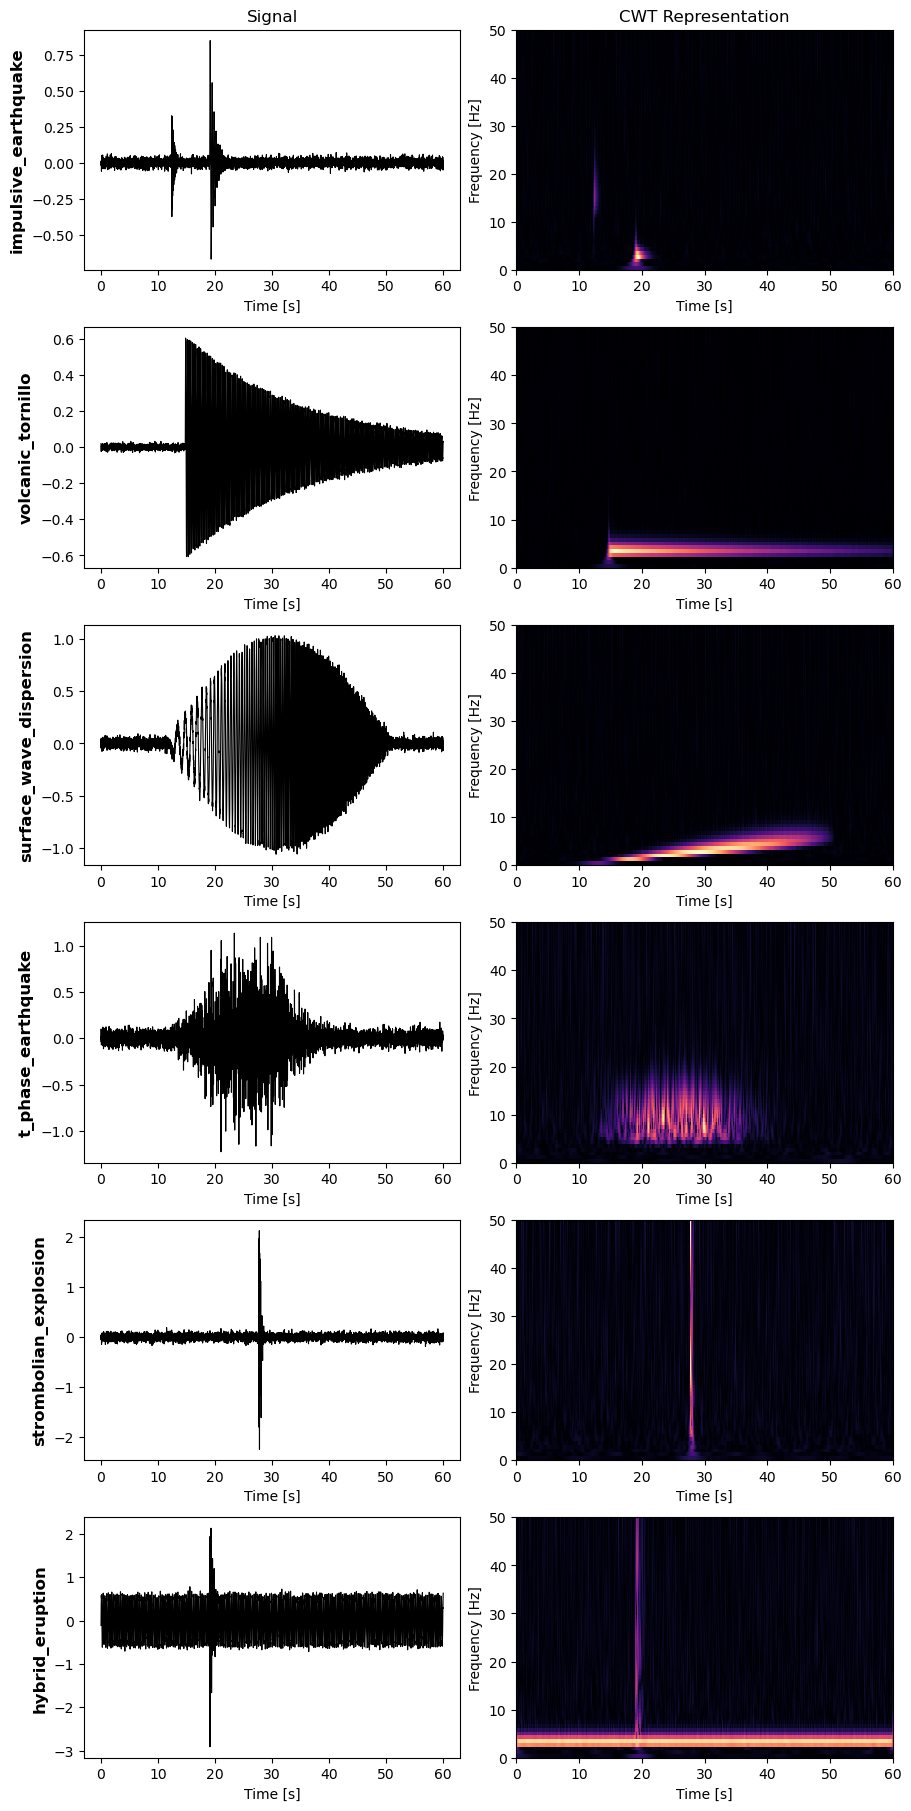

In [ ]:
keys = list(waveform_catalog.keys())
n_keys = len(keys)
n_samples = 1

# 2 columns per sample (Signal + CWT)
fig, axes = plt.subplots(n_keys, n_samples * 2, figsize=(9, 3 * n_keys), constrained_layout=True)

for i, key in enumerate(keys):
    selected_indices = random.sample(range(len(waveform_catalog[key])), n_samples)
    
    for j, idx in enumerate(selected_indices):
        time_series, signal = waveform_catalog[key][idx]
        # Compute CWT
        scales = np.arange(1, 128)
        coef, _ = compute_cwt(signal, fs=100.0, n_scales=64, norm='l2')
        
        # Handle indexing for subplots
        ax_sig = axes[i, j * 2] if n_keys > 1 else axes[j * 2]
        ax_cwt = axes[i, j * 2 + 1] if n_keys > 1 else axes[j * 2 + 1]
        
        # Plot Signal
        ax_sig.plot(time_series, signal, color='black', linewidth=0.8)
        if j ==0:
            ax_sig.set_ylabel(key, fontsize=12, fontweight='bold')
        
        # Plot CWT
        ax_cwt.imshow(np.log1p(coef), aspect='auto', origin='lower', extent=[0,60,0,50], cmap='magma', interpolation='none')
        
        if i == 0:
            ax_sig.set_title(f"Signal")
            ax_cwt.set_title(f"CWT Representation")

        ax_sig.set_xlabel('Time [s]')
        ax_cwt.set_xlabel('Time [s]')
        ax_cwt.set_ylabel('Frequency [Hz]')

#fig.savefig(os.path.join(fig_save_path,'raw_synth_signal_types.svg'),dpi=300)
plt.show()

In [29]:
list_images[0].shape

(32, 6000)

### Generate Spec2Vec Metrics on the Signals

In [27]:
sel_columns = [
       'permutation_entropy_antropy', 
       'spectral_entropy_antropy',
       'svd_entropy_antropy', 
       'petrosian_fd_antropy', 
       'detrended_fluctuation_antropy', 
       'hjorth_mobility_antropy',
       'hjorth_complexity_antropy', 
       'higuchi_fd_antropy',
       'normalized_permutation_entropy_ordpy',
       'statistical_complexity_entropy_ordpy', 
       'fisher_shannon_ordpy',
       'global_node_entropy_ordpy', 
       'renyi_complexity_entropy_long_ordpy',
       'renyi_stat_complexity_long_ordpy',
       'tsallis_complexity_entropy_long_ordpy',
       'tsallis_stat_complexity_long_ordpy',
       'weighted_permutation_entropy_ordpy', 
       'missing_links_ordpy',
       'Absolute energy',
       'Average power',
       'Kurtosis', 'Lempel-Ziv complexity', 'Mean','Median','Skewness', 'Standard deviation',
       '75th_percentile',
       '25th_percentile',
       'label']

In [ ]:
giq = GISQAPipeline()
spec_pointwise_metrics_df = giq.compute_pointwise_metrics_from_spec(list_names, list_images, 
                                                                    is_hilbertize = 1, 
                                                                    is_normalize_stat = 0, 
                                                                    is_normalize_entropy = 0,
                                                                    is_best_features = 0,
                                                                    ordpydx = 6, antropydx=6,
                                                                    metrics_list=sel_columns, hilbert_locs=None)

In [14]:
spec_pointwise_metrics_df

,permutation_entropy_antropy,spectral_entropy_antropy,svd_entropy_antropy,hjorth_mobility_antropy,hjorth_complexity_antropy,petrosian_fd_antropy,higuchi_fd_antropy,detrended_fluctuation_antropy,normalized_permutation_entropy_ordpy,statistical_complexity_entropy_ordpy,fisher_shannon_ordpy,global_node_entropy_ordpy,missing_links_ordpy,renyi_complexity_entropy_long_ordpy,renyi_stat_complexity_long_ordpy,tsallis_complexity_entropy_long_ordpy,tsallis_stat_complexity_long_ordpy,weighted_permutation_entropy_ordpy,0_Absolute energy,0_Average power,0_Kurtosis,0_Lempel-Ziv complexity,0_Mean,0_Median,0_Skewness,0_Standard deviation,75th_percentile,25th_percentile,label
0,0.833366,0.794779,0.851439,0.647227,2.262784,1.013550,1.637282,0.907674,0.833366,0.300571,0.203291,1.264056,0.211343,0.789092,0.354602,0.961238,0.391223,4.395494,1606.722372,0.008368,791.682171,0.035656,0.024063,0.016680,24.971446,0.088257,0.023928,0.010654,impulsive_earthquake_sample0
1,0.830566,0.690896,0.747727,0.396379,3.565274,1.013514,1.501386,0.932937,0.830566,0.303535,0.206985,1.255594,0.216898,0.785758,0.357302,0.960384,0.395896,4.497485,2145.435969,0.011174,513.875990,0.033271,0.026487,0.017164,20.593425,0.102336,0.024935,0.010874,impulsive_earthquake_sample1
2,0.832842,0.749160,0.808619,0.517951,2.761701,1.013553,1.580457,0.894099,0.832842,0.301230,0.204973,1.262614,0.206944,0.788485,0.355204,0.961084,0.392202,4.507898,1480.680924,0.007712,634.722591,0.036349,0.024393,0.017065,22.599082,0.084362,0.024429,0.010766,impulsive_earthquake_sample2
3,0.832429,0.821393,0.846469,0.644352,2.226599,1.013524,1.614226,0.924192,0.832429,0.301372,0.203311,1.259531,0.216667,0.787791,0.355246,0.960906,0.392553,4.557554,1381.222829,0.007194,637.431605,0.035781,0.024662,0.017009,22.236619,0.081152,0.024711,0.010684,impulsive_earthquake_sample3
4,0.832761,0.744400,0.804410,0.598260,2.342110,1.013530,1.645671,0.927278,0.832761,0.301039,0.204004,1.259848,0.213657,0.788267,0.354988,0.961028,0.392039,4.617680,538.956467,0.002807,331.491240,0.040740,0.021722,0.016499,16.337962,0.048324,0.023916,0.010393,impulsive_earthquake_sample4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,0.825849,0.703341,0.777268,0.468164,3.012477,1.013430,1.268363,0.800613,0.825849,0.311458,0.208869,1.238774,0.237037,0.781519,0.364426,0.959284,0.406355,5.031809,20577.728297,0.107176,10.426718,0.014964,0.133307,0.046873,3.445096,0.299006,0.071929,0.028918,hybrid_eruption_sample20
146,0.826139,0.785355,0.840930,0.657728,2.247871,1.013505,1.569353,0.878341,0.826139,0.311803,0.209534,1.235535,0.244444,0.782403,0.365229,0.959515,0.406924,5.007888,9615.239630,0.050080,17.375092,0.018135,0.104212,0.047181,4.004536,0.198038,0.071940,0.029305,hybrid_eruption_sample21
147,0.827971,0.839028,0.907355,0.833324,1.781002,1.013474,1.660551,0.801146,0.827971,0.309432,0.211387,1.244887,0.241204,0.784231,0.362742,0.959990,0.403106,5.012511,62007.197052,0.322956,21.088294,0.014375,0.178963,0.046670,4.654742,0.539376,0.070110,0.028890,hybrid_eruption_sample22
148,0.827709,0.824988,0.921280,1.016591,1.445520,1.013410,1.904623,0.810404,0.827709,0.309852,0.217998,1.247618,0.239815,0.784086,0.363100,0.959952,0.403601,4.488275,62694.618587,0.326536,24.266812,0.013734,0.164032,0.045051,5.049184,0.547383,0.066719,0.028158,hybrid_eruption_sample23


In [ ]:
spec_pointwise_metrics_df_copy = spec_pointwise_metrics_df.copy()

features_list = [clusterimages(img, ncomp=5, isplot=0, image_thresh=80) for img, name in zip(list_images, list_names)]
all_features_df = pd.concat(features_list, ignore_index=True)
spec_pointwise_metrics_df_copy = pd.concat([spec_pointwise_metrics_df_copy, all_features_df], axis=1)

### Applying Clustering on Texture+Stat Columns

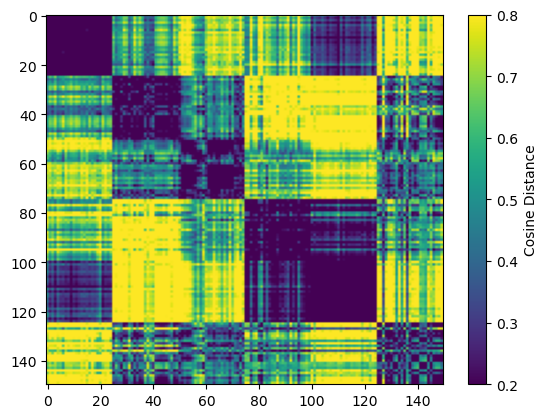

In [ ]:
features = spec_pointwise_metrics_df.drop(columns=['label']).values

scaler = StandardScaler()
features= scaler.fit_transform(features)

cos_dist = cdist(features, features, metric='cosine')
cos_dist = cos_dist/np.max(cos_dist) 

plt.imshow(cos_dist, cmap='viridis', aspect='auto', vmin=0.2, vmax=0.8)
plt.colorbar(label='Cosine Distance')

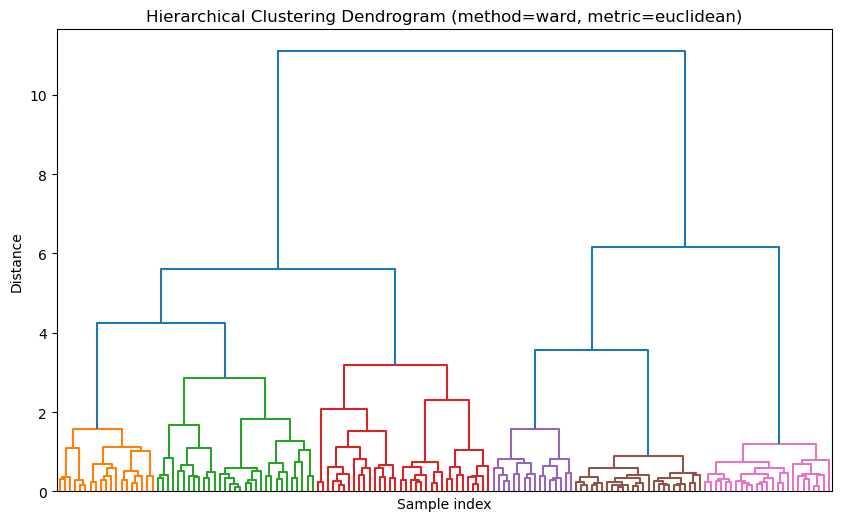

Total Labels:  150


In [ ]:
def perform_hierarchical_clustering(data, method='ward', metric='euclidean', plot_dendrogram=True, color_threshold=None, figsize=(10, 6), savefig=False, savepath=None):
    distance_matrix = pdist(data, metric=metric)
    linkage_matrix = linkage(distance_matrix, method=method,optimal_ordering=True)

    if plot_dendrogram:
        plt.figure(figsize=figsize)
        dendro = dendrogram(linkage_matrix, color_threshold=color_threshold, no_labels=True)            
        plt.title(f'Hierarchical Clustering Dendrogram (method={method}, metric={metric})')
        plt.xlabel('Sample index')
        plt.ylabel('Distance')
        if savefig:
            plt.savefig(savepath, dpi=300)
        plt.show()

    return linkage_matrix 

def merge_clusters(linkage_matrix, num_clusters=None, distance_threshold=None):
    if num_clusters is not None:
        labels = fcluster(linkage_matrix, t=num_clusters, criterion='maxclust')
    elif distance_threshold is not None:
        labels = fcluster(linkage_matrix, t=distance_threshold, criterion='distance')
    else:
        raise ValueError("You must provide either 'num_clusters' or 'distance_threshold'")
    return labels

col_theshold = 3.5
dist_threshold = 3.5
features = spec_pointwise_metrics_df.drop(columns=['label']).values

scaler = StandardScaler()
features= scaler.fit_transform(features)
features = normalize(features, norm='l2')

linkage_matrix = perform_hierarchical_clustering(features,method='ward',metric='euclidean',
                                                plot_dendrogram=True,color_threshold=col_theshold)
hir_labels = merge_clusters(linkage_matrix, distance_threshold=dist_threshold)
print('Total Labels: ', len(hir_labels))

In [20]:
Counter(hir_labels)

Counter({np.int32(3): 34,
         np.int32(2): 31,
         np.int32(6): 25,
         np.int32(5): 25,
         np.int32(1): 19,
         np.int32(4): 16})

In [21]:
hir_labels

array([6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1,
       2, 1, 2, 1, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 4, 3, 4, 3, 3, 3, 4, 3, 4, 3, 4, 3,
       4, 4, 4, 4, 4, 4, 3, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3], dtype=int32)

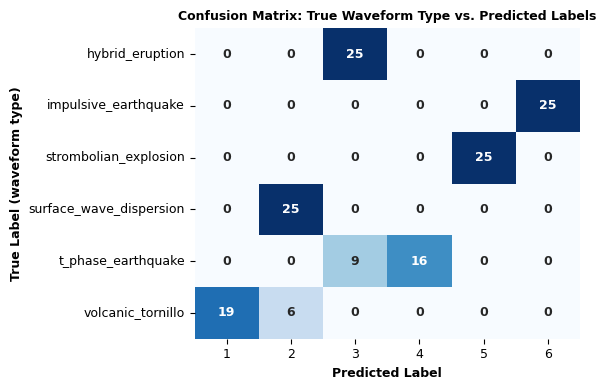

In [22]:
label_map = pd.DataFrame({'labels':hir_labels, 'waveform_type':['_'.join(name.split('_')[:-1]) for name in list_names]})
label_map.sort_values(by='labels',inplace=True)
label_map = label_map.reset_index(drop=True)

cm = pd.crosstab(label_map['waveform_type'], label_map['labels'])

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 9, 'fontweight':'bold'}, cbar=False)
plt.title('Confusion Matrix: True Waveform Type vs. Predicted Labels', fontsize=9, fontweight='bold')
plt.ylabel('True Label (waveform type)',fontsize=9, fontweight='bold')
plt.xlabel('Predicted Label',fontsize=9, fontweight='bold')
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

In [23]:
score = silhouette_score(features, hir_labels)
print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.3585


[100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117
 118 119 120 121 122 123 124]
Looking at Sample:  103


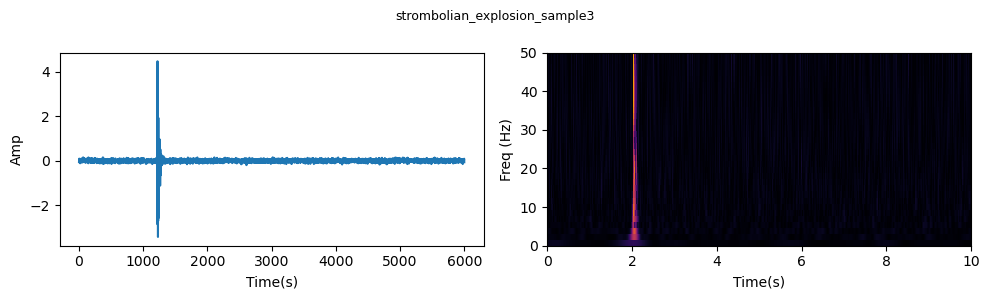

In [ ]:
target_class = 5
target_idxs = np.where(hir_labels==target_class)[0]
print(target_idxs)
target_idx = random.choice(target_idxs)
print('Looking at Sample: ', target_idx)

plt.figure(figsize=(10,3))
plt.subplot(1,2,1); plt.plot(list_ts[target_idx]); plt.xlabel('Time(s)'); plt.ylabel('Amp')
plt.subplot(1,2,2);plt.imshow(np.log1p(list_images[target_idx]), aspect='auto', extent = [0, 10, 0, 50],
                                        origin = 'lower', cmap='inferno', interpolation='none')
plt.xlabel('Time(s)'); plt.ylabel('Freq (Hz)')
plt.suptitle(list_names[target_idx], fontsize=9)
plt.tight_layout()
plt.show()

### Applying Clustering Texture+Text+Spatial Columns

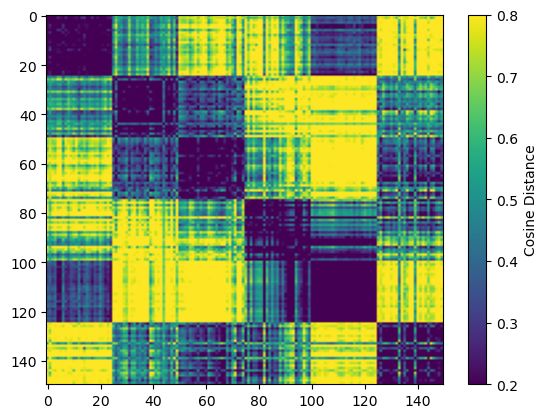

In [ ]:
features = spec_pointwise_metrics_df_copy.drop(columns=['label']).values

scaler = StandardScaler()
features= scaler.fit_transform(features)

cos_dist = cdist(features, features, metric='cosine')
cos_dist = cos_dist/np.max(cos_dist) 

plt.imshow(cos_dist, cmap='viridis', aspect='auto', vmin=0.2, vmax=0.8)
plt.colorbar(label='Cosine Distance')
plt.show()

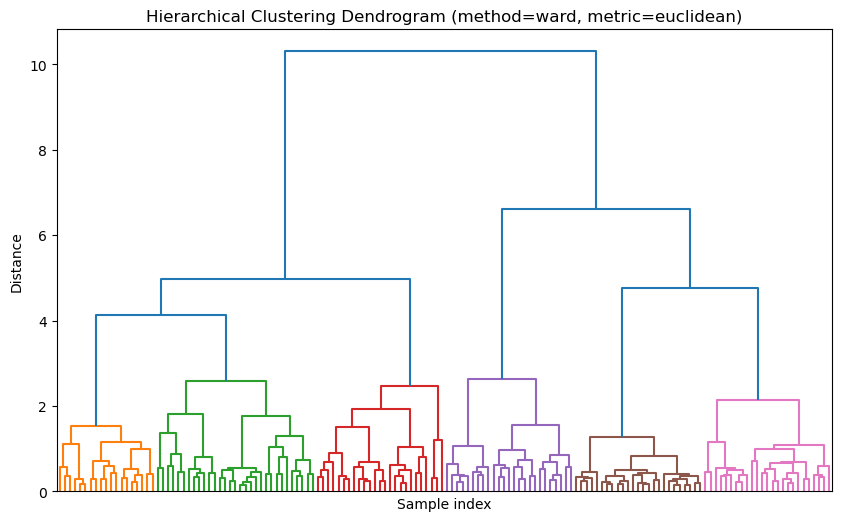

Total Labels:  150


In [ ]:
def perform_hierarchical_clustering(data, method='ward', metric='euclidean', plot_dendrogram=True, color_threshold=None, figsize=(10, 6), savefig=False, savepath=None):
    distance_matrix = pdist(data, metric=metric)
    linkage_matrix = linkage(distance_matrix, method=method,optimal_ordering=True)

    if plot_dendrogram:
        plt.figure(figsize=figsize)
        dendro = dendrogram(linkage_matrix, color_threshold=color_threshold, no_labels=True)            
        plt.title(f'Hierarchical Clustering Dendrogram (method={method}, metric={metric})')
        plt.xlabel('Sample index')
        plt.ylabel('Distance')
        if savefig:
            plt.savefig(savepath, dpi=300)
        plt.show()

    return linkage_matrix 

def merge_clusters(linkage_matrix, num_clusters=None, distance_threshold=None):
    if num_clusters is not None:
        labels = fcluster(linkage_matrix, t=num_clusters, criterion='maxclust')
    elif distance_threshold is not None:
        labels = fcluster(linkage_matrix, t=distance_threshold, criterion='distance')
    else:
        raise ValueError("You must provide either 'num_clusters' or 'distance_threshold'")
    return labels

col_theshold = 3.5#2.6#
dist_threshold = 3.5#2.6#
features = spec_pointwise_metrics_df_copy.drop(columns=['label']).values

scaler = StandardScaler()
features= scaler.fit_transform(features)
features = normalize(features, norm='l2')

linkage_matrix = perform_hierarchical_clustering(features, method='ward',metric='euclidean',
                                                plot_dendrogram=True,color_threshold=col_theshold, savefig=100, savepath=os.path.join(fig_save_path,'dendrogram_results.svg'))
hir_labels = merge_clusters(linkage_matrix, distance_threshold=dist_threshold)
print('Total Labels: ', len(hir_labels))

In [295]:
Counter(hir_labels)

Counter({np.int32(2): 31,
         np.int32(6): 25,
         np.int32(4): 25,
         np.int32(5): 25,
         np.int32(3): 25,
         np.int32(1): 19})

In [250]:
hir_labels

array([6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1,
       2, 1, 2, 1, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3], dtype=int32)

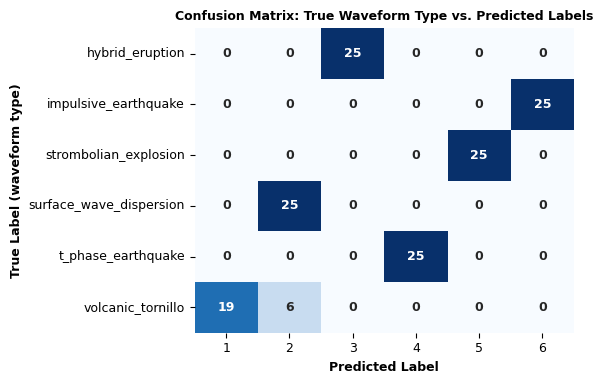

In [370]:
label_map = pd.DataFrame({'labels':hir_labels, 'waveform_type':['_'.join(name.split('_')[:-1]) for name in list_names]})
label_map.sort_values(by='labels',inplace=True)
label_map = label_map.reset_index(drop=True)

cm = pd.crosstab(label_map['waveform_type'], label_map['labels'])

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 9, 'fontweight':'bold'}, cbar=False)
plt.title('Confusion Matrix: True Waveform Type vs. Predicted Labels', fontsize=9, fontweight='bold')
plt.ylabel('True Label (waveform type)',fontsize=9, fontweight='bold')
plt.xlabel('Predicted Label',fontsize=9, fontweight='bold')
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
#plt.savefig(os.path.join(fig_save_path,'confusion_matrix.svg'), dpi=300)
plt.show()

In [252]:
score = silhouette_score(features, hir_labels)
print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.3357


[25 26 35 44 46 48 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67
 68 69 70 71 72 73 74]
Looking at Sample:  63


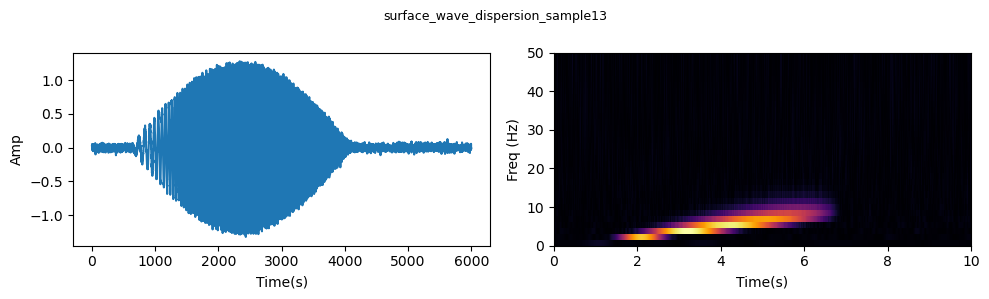

In [ ]:
target_class = 2
target_idxs = np.where(hir_labels==target_class)[0]
print(target_idxs)
target_idx = random.choice(target_idxs)
print('Looking at Sample: ', target_idx)

plt.figure(figsize=(10,3))
plt.subplot(1,2,1); plt.plot(list_ts[target_idx]); plt.xlabel('Time(s)'); plt.ylabel('Amp')
plt.subplot(1,2,2);plt.imshow(np.log1p(list_images[target_idx]), aspect='auto', extent = [0, 10, 0, 50],
                                        origin = 'lower', cmap='inferno', interpolation='none')
plt.xlabel('Time(s)'); plt.ylabel('Freq (Hz)')
plt.suptitle(list_names[target_idx], fontsize=9)
plt.tight_layout()
plt.show()

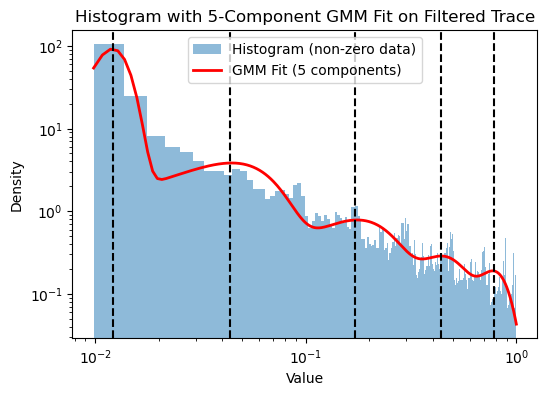

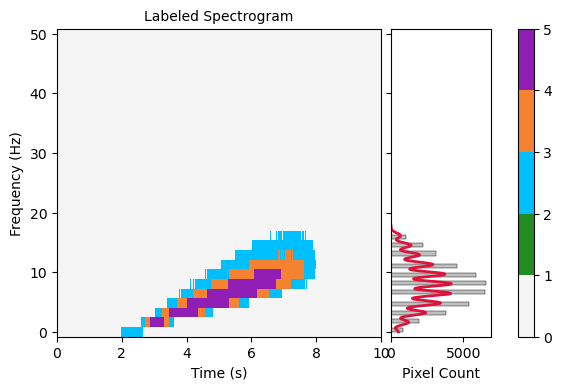

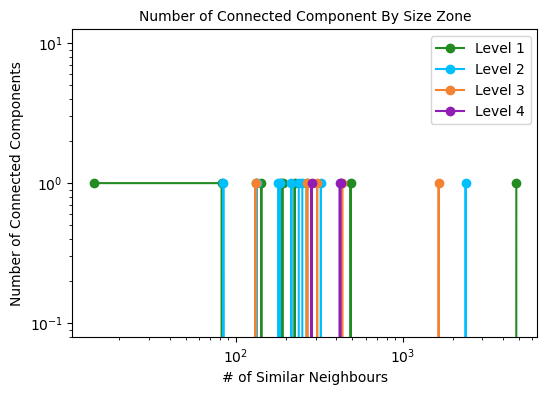

,SmallAreaEmphasis,LargeAreaEmphasis,GrayLevelNonUniformityNormalized,SizeZoneNonUniformityNormalized,LargeAreaHighGrayLevelEmphasis,WeightedZoneSizePercentageFeatureValue
0,0.000218,1.227211e+06,0.294925,0.039781,3.052469e+06,0.02619


In [99]:
clusterimages(list_images[target_idx], ncomp=5, isplot=1, image_thresh=80, ts=np.linspace(0,10,list_images[0].shape[1]), freqs=np.linspace(0,50,list_images[0].shape[0]))

### Checking for the Feature Interpretability

/tmp/ipykernel_927737/1405642382.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=imp_df, palette='viridis')


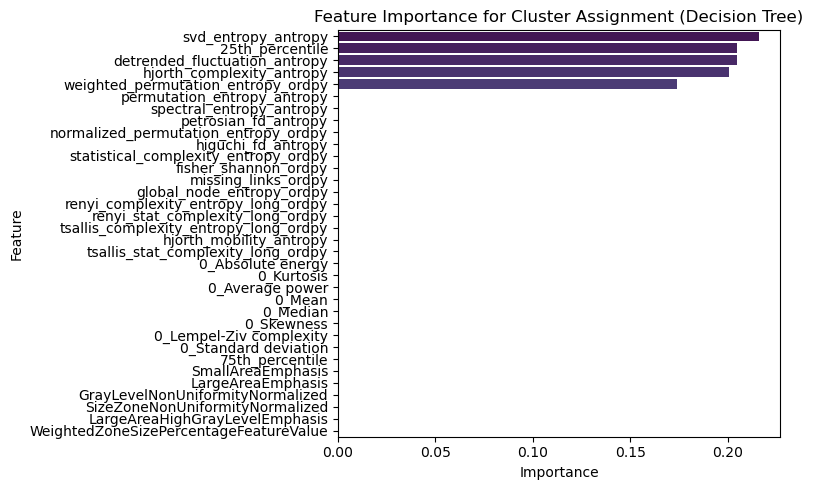

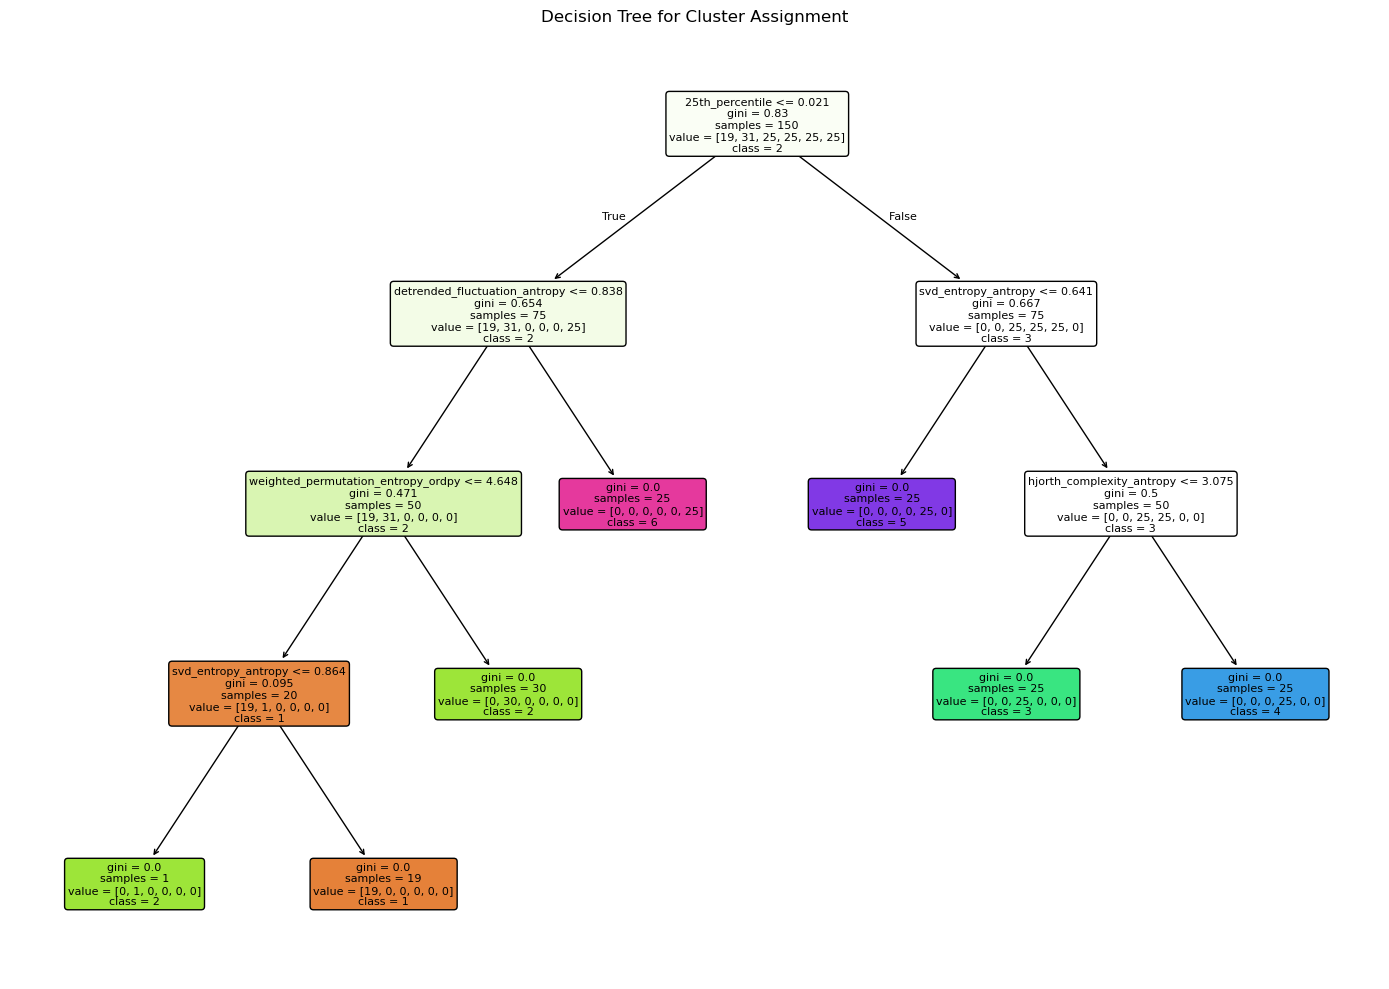

Decision Tree Rules:
 |--- 25th_percentile <= 0.02
|   |--- detrended_fluctuation_antropy <= 0.84
|   |   |--- weighted_permutation_entropy_ordpy <= 4.65
|   |   |   |--- svd_entropy_antropy <= 0.86
|   |   |   |   |--- class: 2
|   |   |   |--- svd_entropy_antropy >  0.86
|   |   |   |   |--- class: 1
|   |   |--- weighted_permutation_entropy_ordpy >  4.65
|   |   |   |--- class: 2
|   |--- detrended_fluctuation_antropy >  0.84
|   |   |--- class: 6
|--- 25th_percentile >  0.02
|   |--- svd_entropy_antropy <= 0.64
|   |   |--- class: 5
|   |--- svd_entropy_antropy >  0.64
|   |   |--- hjorth_complexity_antropy <= 3.08
|   |   |   |--- class: 3
|   |   |--- hjorth_complexity_antropy >  3.08
|   |   |   |--- class: 4



In [220]:
# Analyze feature interpretability using Decision Tree classifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
import seaborn as sns

# Prepare features and labels
features = spec_pointwise_metrics_df_copy.drop(columns=['label']).values
feature_names = list(spec_pointwise_metrics_df_copy.drop(columns=['label']).columns)
labels = hir_labels

#scaler = StandardScaler()
#scaler = RobustScaler()
#features= scaler.fit_transform(features)
#features = normalize(features, norm='l2')

# Fit Decision Tree
clf = DecisionTreeClassifier(max_depth=6, random_state=42)
clf.fit(features, labels)

# Feature importance
importances = clf.feature_importances_
imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
imp_df = imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=imp_df, palette='viridis')
plt.title('Feature Importance for Cluster Assignment (Decision Tree)')
plt.tight_layout()
plt.show()

# Visualize the tree structure
plt.figure(figsize=(14, 10))
plot_tree(clf, feature_names=feature_names, class_names=[str(c) for c in np.unique(labels)], filled=True, rounded=True, fontsize=8)
plt.title('Decision Tree for Cluster Assignment')
plt.tight_layout()
plt.show()

# Print top rules
from sklearn.tree import export_text
rules = export_text(clf, feature_names=feature_names)
print('Decision Tree Rules:\n', rules)

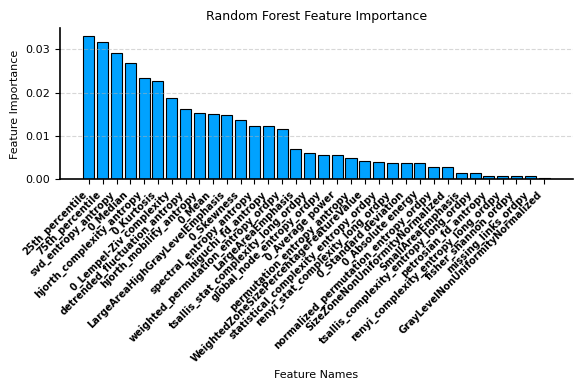

In [276]:
features = spec_pointwise_metrics_df_copy.drop(columns=['label']).values
feature_names = list(spec_pointwise_metrics_df_copy.drop(columns=['label']).columns)

#scaler = StandardScaler()
#features= scaler.fit_transform(features)
#features = normalize(features, norm='l2')

rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(features, hir_labels)

shap.initjs()
explainer = shap.TreeExplainer(rf_clf)
shap_values_stat = explainer(features)
_, feature_imp_df = HelperFunc.print_feature_importances_shap_values(shap_values_stat, feature_names)

plt.figure(figsize=(6, 4))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(1.2)
plt.gca().spines['bottom'].set_linewidth(1.2)
plt.bar(feature_imp_df['index'], feature_imp_df['vals'], color="#00A2FF", edgecolor='black', linewidth=0.8)
plt.xlabel('Feature Names',fontsize=8); plt.ylabel('Feature Importance',fontsize=8)
plt.xticks(rotation=45, ha='right', fontsize=7, fontweight='bold'); plt.yticks(fontsize=8)
plt.title('Random Forest Feature Importance', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib
from sklearn.inspection import permutation_importance
from sklearn.utils.fixes import parse_version
from sklearn.inspection import permutation_importance
from sklearn.utils.fixes import parse_version
#result = permutation_importance(clf, features, hir_labels, n_repeats=20, random_state=42)

def plot_permutation_importance(clf, X, y, feature_names, ax):
    result = permutation_importance(clf, X, y, n_repeats=25, random_state=42, n_jobs=2)
    perm_sorted_idx = result.importances_mean.argsort()

    tick_labels_parameter_name = (
        "tick_labels"
        if parse_version(matplotlib.__version__) >= parse_version("3.9")
        else "labels"
    )
    tick_labels_dict = {tick_labels_parameter_name: np.array(feature_names)[perm_sorted_idx]}
    ax.boxplot(result.importances[perm_sorted_idx].T, vert=False, **tick_labels_dict)
    ax.axvline(x=0, color="k", linestyle="--")
    ax.figure.tight_layout()

    return ax

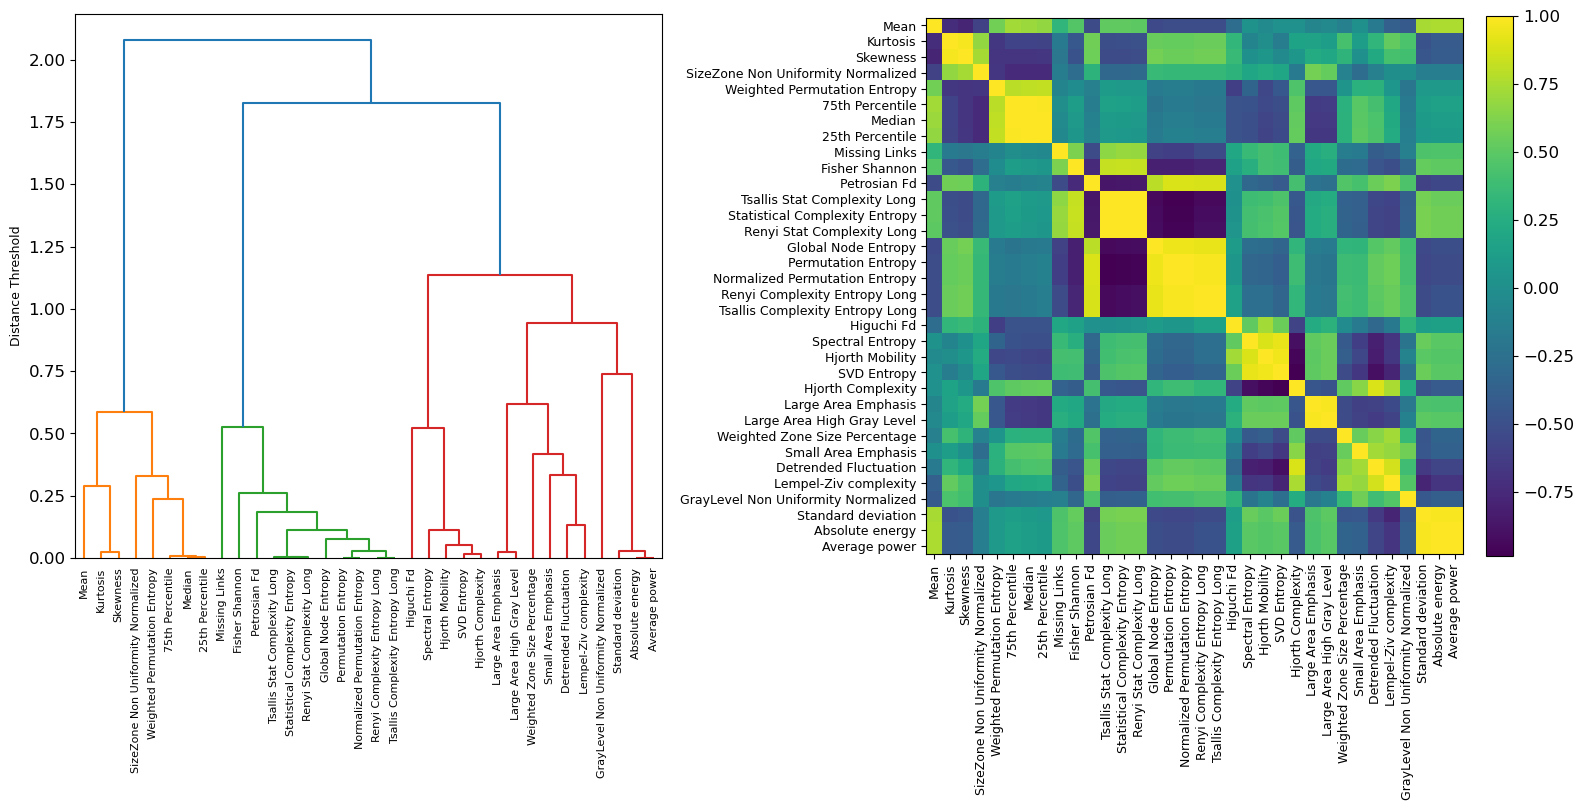

In [322]:
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr

features = spec_pointwise_metrics_df_copy.drop(columns=['label']).values
feature_names = list(spec_pointwise_metrics_df_copy.drop(columns=['label']).columns)
feature_names_print = ['Permutation Entropy', 'Spectral Entropy', 'SVD Entropy', 'Hjorth Mobility',
'Hjorth Complexity', 'Petrosian Fd', 'Higuchi Fd', 'Detrended Fluctuation',
'Normalized Permutation Entropy', 'Statistical Complexity Entropy', 'Fisher Shannon', 'Global Node Entropy',
'Missing Links','Renyi Complexity Entropy Long', 'Renyi Stat Complexity Long', 'Tsallis Complexity Entropy Long', 'Tsallis Stat Complexity Long', 
'Weighted Permutation Entropy', 'Absolute energy','Average power','Kurtosis','Lempel-Ziv complexity',
'Mean','Median','Skewness','Standard deviation','75th Percentile','25th Percentile',
'Small Area Emphasis','Large Area Emphasis','GrayLevel Non Uniformity Normalized','SizeZone Non Uniformity Normalized',
'Large Area High Gray Level','Weighted Zone Size Percentage']

scaler = StandardScaler()
features = scaler.fit_transform(features)
features = normalize(features, norm='l2')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

corr = spearmanr(features).correlation
corr = (corr + corr.T) / 2
np.fill_diagonal(corr, 1)

# We convert the correlation matrix to a distance matrix before performing
# hierarchical clustering using Ward's linkage.
distance_matrix = 1 - np.abs(corr)
dist_linkage = hierarchy.ward(squareform(distance_matrix))

dendro = hierarchy.dendrogram(
    dist_linkage, labels=feature_names_print, ax=ax1, leaf_rotation=90
)
dendro_idx = np.arange(0, len(dendro["ivl"]))
ax1.set_ylabel('Distance Threshold', fontsize=9)

ax2.imshow(corr[dendro["leaves"], :][:, dendro["leaves"]])
ax2.set_xticks(dendro_idx)
ax2.set_yticks(dendro_idx)
ax2.set_xticklabels(dendro["ivl"], rotation="vertical", fontsize=9)
ax2.set_yticklabels(dendro["ivl"], fontsize=9)
plt.colorbar(ax2.images[0], ax=ax2, orientation='vertical', fraction=0.046, pad=0.04)
_ = fig.tight_layout()
plt.savefig(os.path.join(fig_save_path,'column_correlation_analysis.svg'), dpi=300)

In [415]:
from collections import defaultdict

features = spec_pointwise_metrics_df_copy.drop(columns=['label']).values
feature_names = list(spec_pointwise_metrics_df_copy.drop(columns=['label']).columns)

cluster_ids = hierarchy.fcluster(dist_linkage, 0.75, criterion="distance")
cluster_id_to_feature_ids = defaultdict(list)
for idx, cluster_id in enumerate(cluster_ids):
    cluster_id_to_feature_ids[cluster_id].append(idx)
selected_features = [v[0] for v in cluster_id_to_feature_ids.values()]
selected_features_names = np.array(feature_names)[selected_features]
selected_features_names_print = np.array(feature_names_print)[selected_features]

# scaler = StandardScaler()
# features= scaler.fit_transform(features)
# features = normalize(features, norm='l2')

X_train, X_test, y_train, y_test = train_test_split(
    features, hir_labels, test_size=0.35, random_state=42, stratify=hir_labels)
X_train_sel = X_train[:, selected_features]
X_test_sel = X_test[:, selected_features]

clf_sel = RandomForestClassifier(n_estimators=25, random_state=42)
clf_sel.fit(X_train_sel, y_train)
print(
    "Accuracy on train data with selected features:"
    f" {clf_sel.score(X_train_sel, y_train):.2}"
)
print(
    "Accuracy on test data with selected features:"
    f" {clf_sel.score(X_test_sel, y_test):.2}"
)
print(f"% of test accuracy is {(clf_sel.score(X_test_sel, y_test)*100):.2f}%")

print("When Applying on the Full Data Set")
X_full = features[:, selected_features]
clf_sel = RandomForestClassifier(n_estimators=100, random_state=42)
clf_sel.fit(X_full, hir_labels)
print(
    "Baseline accuracy on full data with features removed:"
    f" {clf_sel.score(X_full, hir_labels):.2}"
)
print(f"% of accuracy is {((clf_sel.predict(X_full)==hir_labels).sum()/len(hir_labels))*100}%")

Accuracy on train data with selected features: 1.0
Accuracy on test data with selected features: 0.98
% of test accuracy is 98.11%
When Applying on the Full Data Set
Baseline accuracy on full data with features removed: 1.0
% of accuracy is 100.0%


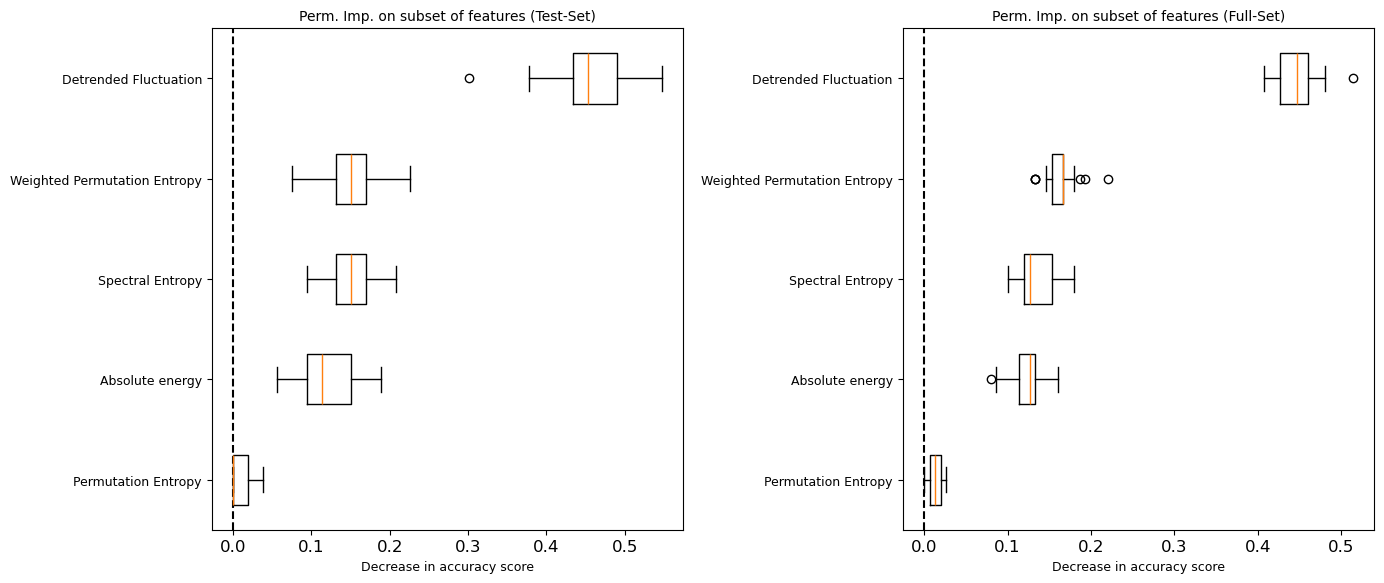

In [416]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(14, 6))
# matplotlib.rcParams.update({'font.size': 12})

plot_permutation_importance(clf_sel, X_test_sel, y_test, selected_features_names_print, ax1)
ax1.set_title("Perm. Imp. on subset of features (Test-Set)",fontsize=10)
ax1.set_xlabel("Decrease in accuracy score", fontsize=9)
ax1.tick_params(axis='y', labelsize=9)
ax2.figure.tight_layout()

plot_permutation_importance(clf_sel, X_full, hir_labels, selected_features_names_print, ax2)
ax2.set_title("Perm. Imp. on subset of features (Full-Set)",fontsize=10)
ax2.set_xlabel("Decrease in accuracy score", fontsize=9)
ax2.tick_params(axis='y', labelsize=9)
ax2.figure.tight_layout()

plt.savefig(os.path.join(fig_save_path,'permuation_importance.svg'), dpi=300)
plt.show()

(150, 5)


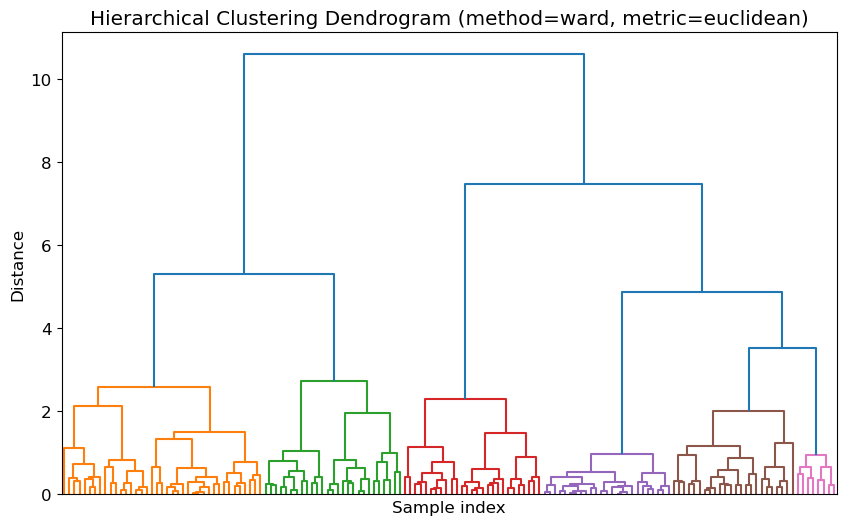

Total Labels:  150


In [ ]:
col_theshold = 3.5
dist_threshold = 3.5

selected_features_names_lst = selected_features_names.flatten().tolist()+['label']
selected_features_names_pnrtlst = selected_features_names_print.flatten().tolist()+['label']
rf_permc_features = spec_pointwise_metrics_df_copy[selected_features_names_lst].drop(columns=['label']).values
print(rf_permc_features.shape)

scaler = StandardScaler()
rf_permc_features= scaler.fit_transform(rf_permc_features)
rf_permc_features = normalize(rf_permc_features, norm='l2')

rfperc_linkage_matrix = perform_hierarchical_clustering(rf_permc_features,method='ward',metric='euclidean',
                                                        plot_dendrogram=True,color_threshold=col_theshold)
rf_permc_hir_labels = merge_clusters(rfperc_linkage_matrix, distance_threshold=dist_threshold)
print('Total Labels: ', len(rf_permc_hir_labels))

In [418]:
Counter(rf_permc_hir_labels)

Counter({np.int32(1): 39,
         np.int32(3): 27,
         np.int32(2): 27,
         np.int32(4): 25,
         np.int32(5): 24,
         np.int32(6): 8})

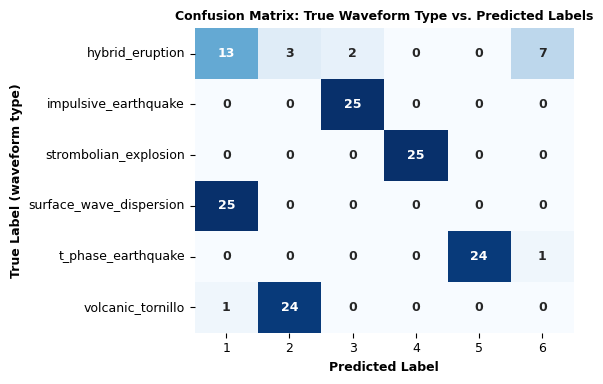

In [419]:
label_map = pd.DataFrame({'labels':rf_permc_hir_labels, 'waveform_type':['_'.join(name.split('_')[:-1]) for name in list_names]})
label_map.sort_values(by='labels',inplace=True)
label_map = label_map.reset_index(drop=True)

cm = pd.crosstab(label_map['waveform_type'], label_map['labels'])

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 9, 'fontweight':'bold'}, cbar=False)
plt.title('Confusion Matrix: True Waveform Type vs. Predicted Labels', fontsize=9, fontweight='bold')
plt.ylabel('True Label (waveform type)',fontsize=9, fontweight='bold')
plt.xlabel('Predicted Label',fontsize=9, fontweight='bold')
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(fig_save_path,'confusion_matrix_on_subset.svg'), dpi=300)
plt.show()

In [420]:
score = silhouette_score(rf_permc_features, rf_permc_hir_labels) #
print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.3820


### Plotting Decison Tree For Feature Interpretability

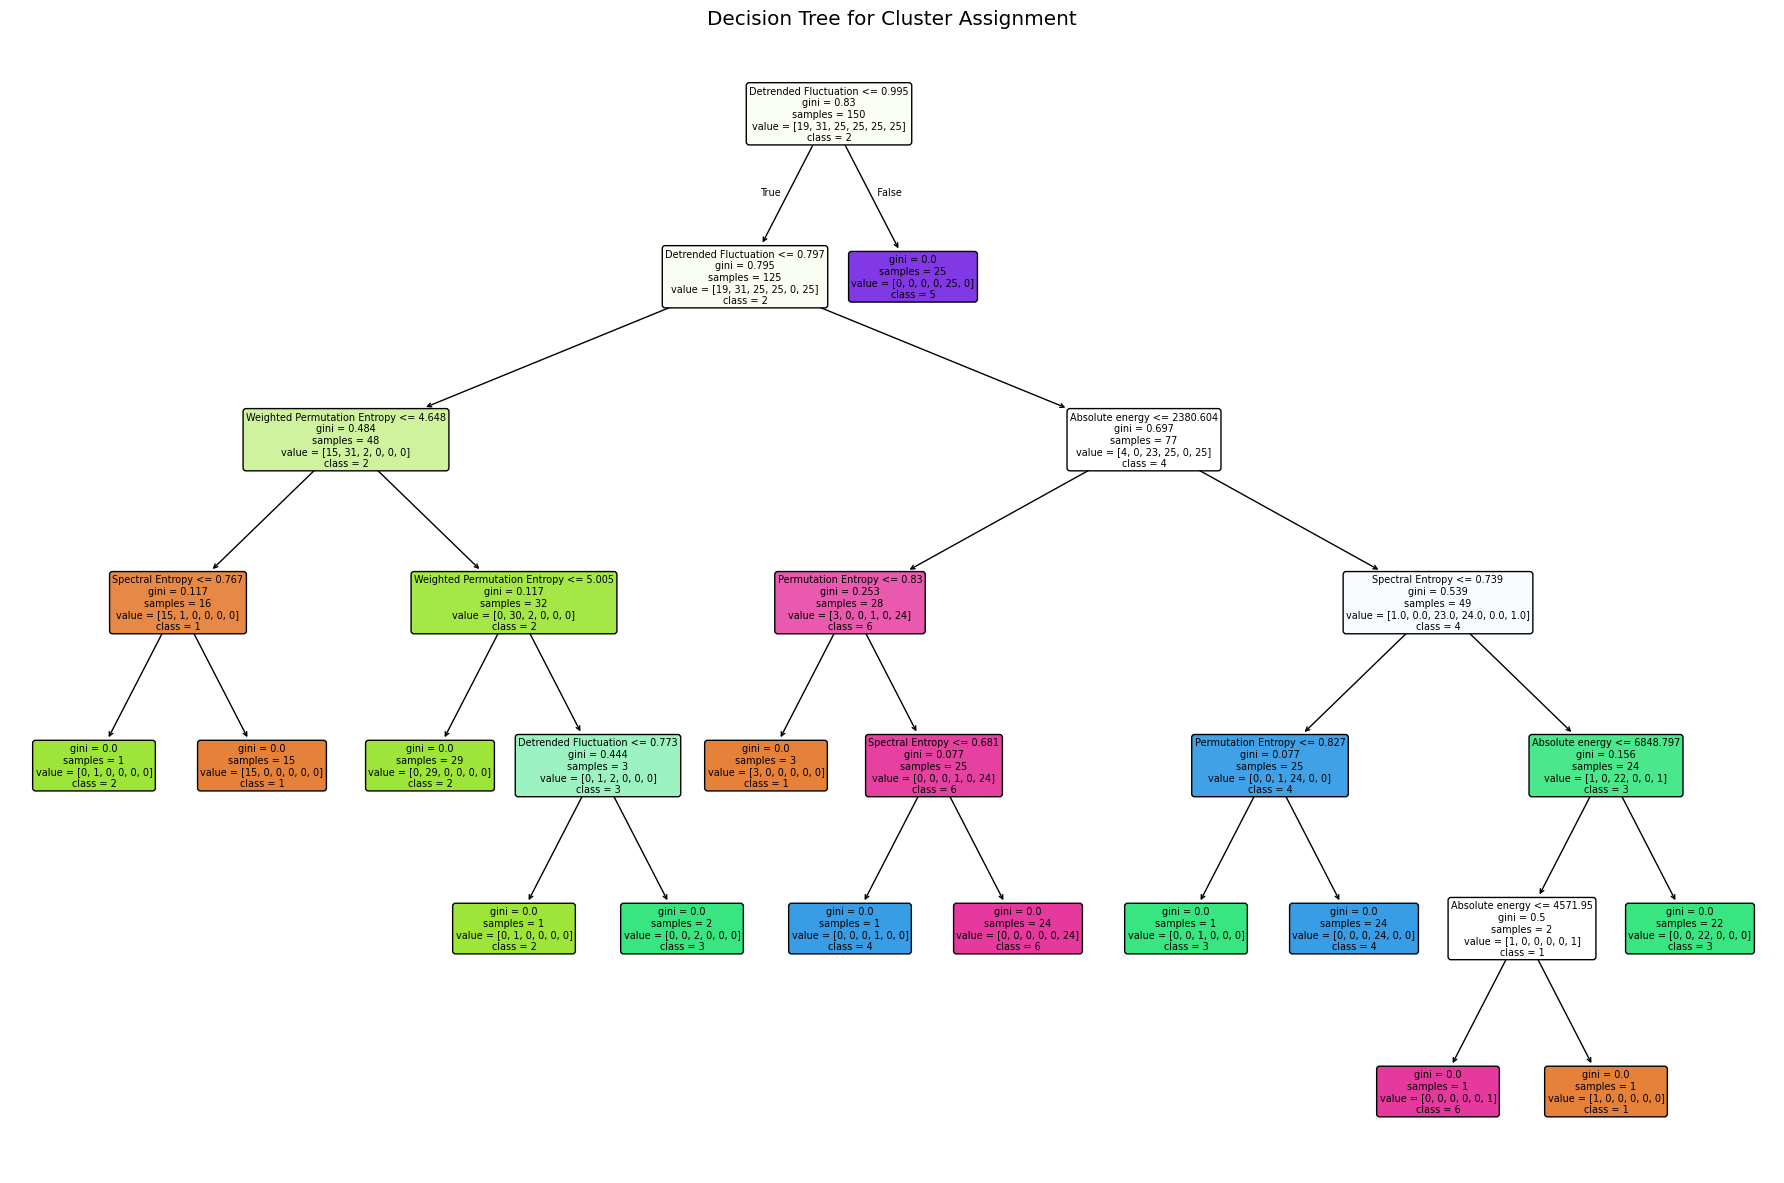

Decision Tree Rules:
 |--- Detrended Fluctuation <= 1.00
|   |--- Detrended Fluctuation <= 0.80
|   |   |--- Weighted Permutation Entropy <= 4.65
|   |   |   |--- Spectral Entropy <= 0.77
|   |   |   |   |--- class: 2
|   |   |   |--- Spectral Entropy >  0.77
|   |   |   |   |--- class: 1
|   |   |--- Weighted Permutation Entropy >  4.65
|   |   |   |--- Weighted Permutation Entropy <= 5.01
|   |   |   |   |--- class: 2
|   |   |   |--- Weighted Permutation Entropy >  5.01
|   |   |   |   |--- Detrended Fluctuation <= 0.77
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- Detrended Fluctuation >  0.77
|   |   |   |   |   |--- class: 3
|   |--- Detrended Fluctuation >  0.80
|   |   |--- Absolute energy <= 2380.60
|   |   |   |--- Permutation Entropy <= 0.83
|   |   |   |   |--- class: 1
|   |   |   |--- Permutation Entropy >  0.83
|   |   |   |   |--- Spectral Entropy <= 0.68
|   |   |   |   |   |--- class: 4
|   |   |   |   |--- Spectral Entropy >  0.68
|   |   |   |   |   |--- cl

In [369]:
selected_features_names_lst = selected_features_names.flatten().tolist()+['label']
selected_features_names_pnrtlst = selected_features_names_print.flatten().tolist()+['label']
rf_permc_dc_features = spec_pointwise_metrics_df_copy[selected_features_names_lst].drop(columns=['label']).values

# Fit Decision Tree
rf_permc_dcclf = DecisionTreeClassifier(max_depth=6, random_state=42)
rf_permc_dcclf.fit(rf_permc_dc_features, hir_labels)

# Visualize the tree structure
plt.figure(figsize=(18, 12))
plot_tree(rf_permc_dcclf, feature_names=selected_features_names_pnrtlst[:-1], class_names=[str(c) for c in np.unique(hir_labels)], filled=True, rounded=True, fontsize=7)
plt.title('Decision Tree for Cluster Assignment')
plt.tight_layout()
plt.savefig(os.path.join(fig_save_path,'decision_tree_on_subset.svg'), dpi=300)
plt.show()

# Print top rules
from sklearn.tree import export_text
rf_permc_dc_rules = export_text(rf_permc_dcclf, feature_names=selected_features_names_pnrtlst[:-1])
print('Decision Tree Rules:\n', rf_permc_dc_rules)